# Milestone 5 — Zero-Shot Power Flow Evaluation

In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds, evaluate as ev
from gridfm.model import GridFMv01

RAW_DIR, PROC_DIR = ROOT / "data" / "raw", ROOT / "data" / "processed"
FIG_DIR, STATS_DIR = ROOT / "results" / "figures" / "m5", ROOT / "results" / "m5_stats"
for d in [FIG_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

GRIDS = ["case24", "case30", "case118"]
GRID_COLORS = {"case24": "#4269D0", "case30": "#EFB118", "case118": "#FF725C"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

model = GridFMv01(per_head=32, heads=4, num_layers=4, dropout=0.1)
state = torch.load(ROOT / "checkpoints" / "final_pretrain_best.pt", weights_only=False)
model.load_state_dict(state["model"])
print("loaded pre-trained weights (best epoch %d)" % state["epoch"])

loaded pre-trained weights (best epoch 183)

## GridFM under the power-flow exam

In [2]:
results, details, test_sets = {}, {}, {}
for g in GRIDS:
    test_sets[g] = ds.load_processed(PROC_DIR, g, "test")
    df, det, _ = ev.pf_evaluate(model, test_sets[g])
    results[g], details[g] = df, det
    print("%-8s %3d test scenarios | mean Pr %7.3f MW | mean Qr %7.3f MVar"
          % (g, len(df), df.p_res_mw.mean(), df.q_res_mvar.mean()))
    results[g].to_csv(STATS_DIR / ("gridfm_%s.csv" % g), index=False)

case24   186 test scenarios | mean Pr  55.561 MW | mean Qr  31.993 MVar

case30   182 test scenarios | mean Pr   4.887 MW | mean Qr   5.440 MVar

case118  188 test scenarios | mean Pr 135.512 MW | mean Qr  54.399 MVar

## The DC solver baseline

In [3]:
import multiprocessing as mp

dc_results = {}
for g in GRIDS:
    meta = pd.read_csv(RAW_DIR / g / "meta.csv").set_index("scenario")
    ybus_all = pd.read_csv(RAW_DIR / g / "ybus.csv")
    sids = [int(d.scenario) for d in test_sets[g]]
    tasks = [(g, s, float(meta.loc[s, "scale"]),
              meta.loc[s, "removed"] if isinstance(meta.loc[s, "removed"], str) else "")
             for s in sids]
    t0 = time.time()
    if __name__ == "__main__":
        with mp.Pool(10) as pool:
            states = pool.map(ev.dc_state_worker, tasks, chunksize=4)
    rows = []
    for st in states:
        if st["status"] != "ok":
            continue
        yb = ybus_all[ybus_all.scenario == st["scenario"]]
        rows.append({"scenario": st["scenario"],
                     "p_res_mw": ev.dc_residual_mw(st["theta"], st["p_inj_mw"], yb)})
    dc_results[g] = pd.DataFrame(rows)
    print("%-8s DC baseline on %d/%d scenarios (%.0fs) | mean Pr %.3f MW"
          % (g, len(rows), len(tasks), time.time() - t0, dc_results[g].p_res_mw.mean()))
    dc_results[g].to_csv(STATS_DIR / ("dc_%s.csv" % g), index=False)

case24   DC baseline on 186/186 scenarios (28s) | mean Pr 3.575 MW

case30   DC baseline on 182/182 scenarios (25s) | mean Pr 1.203 MW

case118  DC baseline on 188/188 scenarios (36s) | mean Pr 2.644 MW

## Scoreboard

         AC solver Pr (MW)  DC solver Pr (MW)  GridFM v0.1 Pr (MW)  GridFM v0.1 Qr (MVar)
case24                 0.0             3.5751              55.5611                31.9927
case30                 0.0             1.2031               4.8870                 5.4399
case118                0.0             2.6440             135.5115                54.3988


Thesis (450k samples, 7.4M params) for qualitative context:

         DC Pr  GridFMv0.1 Pr  GridFMv0.1 Qr
case24   18.61         23.810          7.815
case30    3.99          4.986          2.308
case118  29.33         13.410          3.995

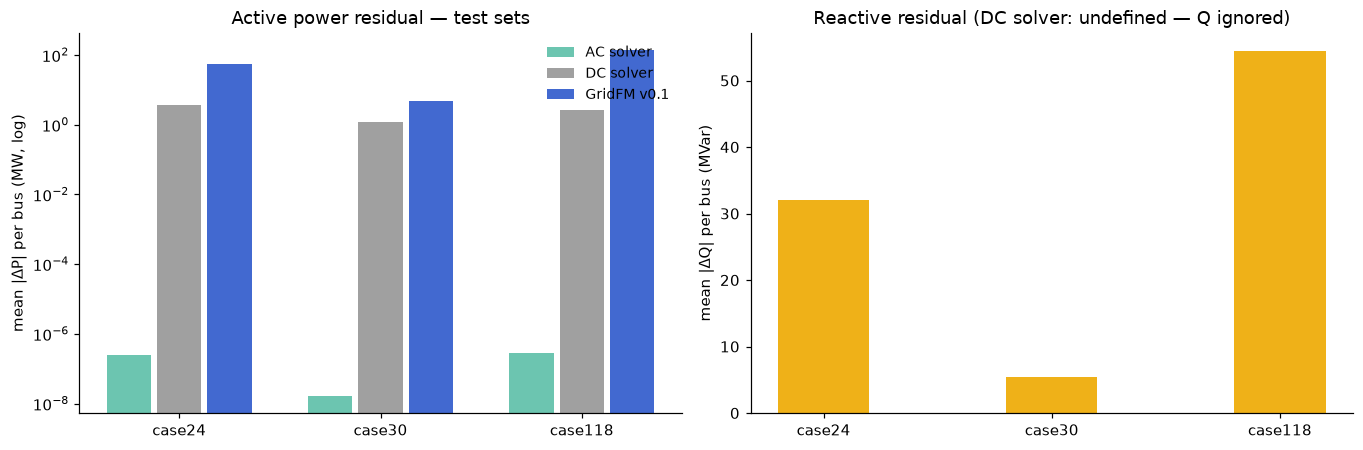

In [4]:
ac_res = {g: pd.read_csv(RAW_DIR / g / "meta.csv").set_index("scenario")
              .loc[[int(d.scenario) for d in test_sets[g]], "residual_mva"].mean()
          for g in GRIDS}
score = pd.DataFrame({
    "AC solver Pr (MW)": {g: ac_res[g] for g in GRIDS},
    "DC solver Pr (MW)": {g: dc_results[g].p_res_mw.mean() for g in GRIDS},
    "GridFM v0.1 Pr (MW)": {g: results[g].p_res_mw.mean() for g in GRIDS},
    "GridFM v0.1 Qr (MVar)": {g: results[g].q_res_mvar.mean() for g in GRIDS},
})
print(score.round(4).to_string())
score.to_csv(STATS_DIR / "scoreboard.csv")

# thesis values for context (Table 5.2/5.3, zero-shot after pre-training, full scale)
thesis = pd.DataFrame({
    "DC Pr": {"case24": 18.61, "case30": 3.99, "case118": 29.33},
    "GridFMv0.1 Pr": {"case24": 23.81, "case30": 4.986, "case118": 13.41},
    "GridFMv0.1 Qr": {"case24": 7.815, "case30": 2.308, "case118": 3.995},
})
print("\nThesis (450k samples, 7.4M params) for qualitative context:")
print(thesis.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
xpos = np.arange(len(GRIDS))
for k, (label, col) in enumerate([("AC solver Pr (MW)", "#6CC5B0"),
                                  ("DC solver Pr (MW)", "#A0A0A0"),
                                  ("GridFM v0.1 Pr (MW)", "#4269D0")]):
    axes[0].bar(xpos + 0.25 * k, score[label].values, width=0.22, color=col,
                label=label.replace(" Pr (MW)", ""))
axes[0].set_yscale("log")
axes[0].set_xticks(xpos + 0.25); axes[0].set_xticklabels(GRIDS)
axes[0].set(ylabel="mean |ΔP| per bus (MW, log)", title="Active power residual — test sets")
axes[0].legend(frameon=False, fontsize=9)

axes[1].bar(xpos, score["GridFM v0.1 Qr (MVar)"].values, width=0.4, color="#EFB118")
axes[1].set_xticks(xpos); axes[1].set_xticklabels(GRIDS)
axes[1].set(ylabel="mean |ΔQ| per bus (MVar)",
            title="Reactive residual (DC solver: undefined — Q ignored)")
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_scoreboard.png", bbox_inches="tight")
plt.show()

## Voltage Scatter

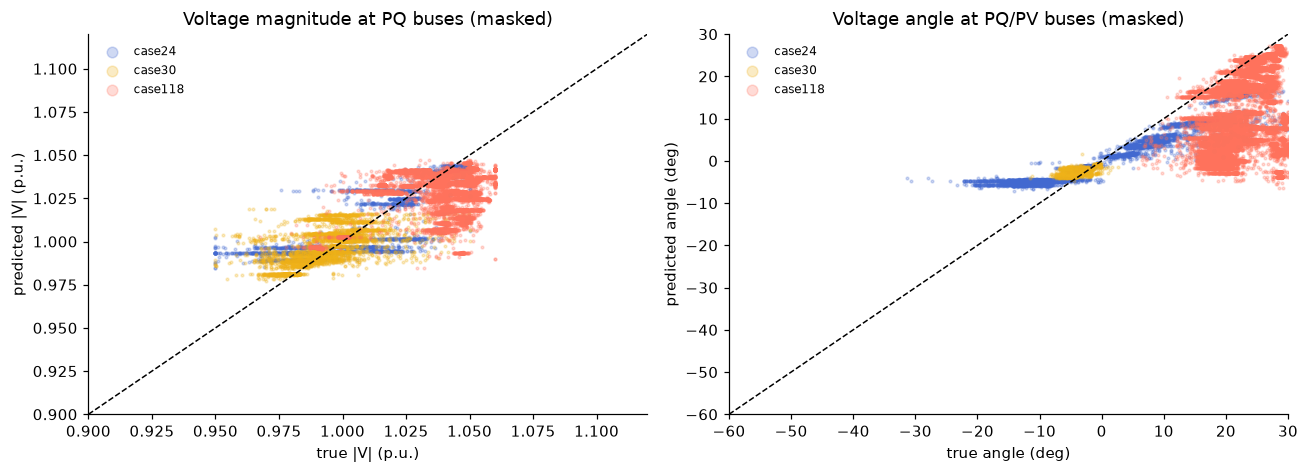

case24   |V| error: mean 0.0114 p.u. (p95 0.0307) | angle error: mean 5.11 deg (p95 12.71)

case30   |V| error: mean 0.0074 p.u. (p95 0.0252) | angle error: mean 1.14 deg (p95 3.04)

case118  |V| error: mean 0.0161 p.u. (p95 0.0365) | angle error: mean 12.37 deg (p95 26.70)

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for g in GRIDS:
    axes[0].scatter(details[g]["vm_true"], details[g]["vm_pred"], s=3, alpha=0.25,
                    color=GRID_COLORS[g], label=g)
    axes[1].scatter(np.rad2deg(details[g]["va_true"]), np.rad2deg(details[g]["va_pred"]),
                    s=3, alpha=0.25, color=GRID_COLORS[g], label=g)
lims0 = [0.90, 1.12]
axes[0].plot(lims0, lims0, "k--", lw=1)
axes[0].set(xlabel="true |V| (p.u.)", ylabel="predicted |V| (p.u.)",
            title="Voltage magnitude at PQ buses (masked)", xlim=lims0, ylim=lims0)
lims1 = [-60, 30]
axes[1].plot(lims1, lims1, "k--", lw=1)
axes[1].set(xlabel="true angle (deg)", ylabel="predicted angle (deg)",
            title="Voltage angle at PQ/PV buses (masked)", xlim=lims1, ylim=lims1)
for a in axes:
    a.legend(frameon=False, fontsize=8, markerscale=4)
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_scatter.png", bbox_inches="tight")
plt.show()
for g in GRIDS:
    vm_err = np.abs(np.array(details[g]["vm_pred"]) - np.array(details[g]["vm_true"]))
    va_err = np.rad2deg(np.abs(np.array(details[g]["va_pred"]) - np.array(details[g]["va_true"])))
    print("%-8s |V| error: mean %.4f p.u. (p95 %.4f) | angle error: mean %.2f deg (p95 %.2f)"
          % (g, vm_err.mean(), np.percentile(vm_err, 95), va_err.mean(), np.percentile(va_err, 95)))

## A voltage profile

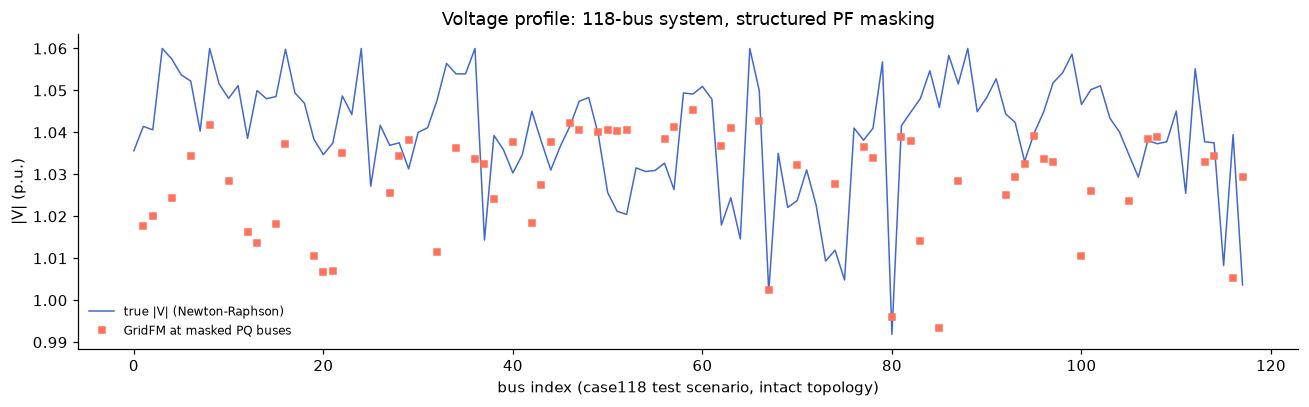

In [6]:
g118 = test_sets["case118"]
intact = next(gr for gr in g118 if gr.n_removed == 0)
xm, m = ds.pf_mask(intact.x)
with torch.no_grad():
    pred = model(xm, intact.edge_index, intact.edge_attr)
vm_true = intact.x[:, 4].numpy()
idx = np.where(m[:, 4].numpy())[0]

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(vm_true, "-", color="#4269D0", lw=1, label="true |V| (Newton-Raphson)")
ax.plot(idx, pred[idx, 4].numpy(), "s", color="#FF725C", ms=3.5,
        label="GridFM at masked PQ buses")
ax.set(xlabel="bus index (case118 test scenario, intact topology)", ylabel="|V| (p.u.)",
       title="Voltage profile: 118-bus system, structured PF masking")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "f3_voltage_profile.png", bbox_inches="tight")
plt.show()

## Error map and error distributions

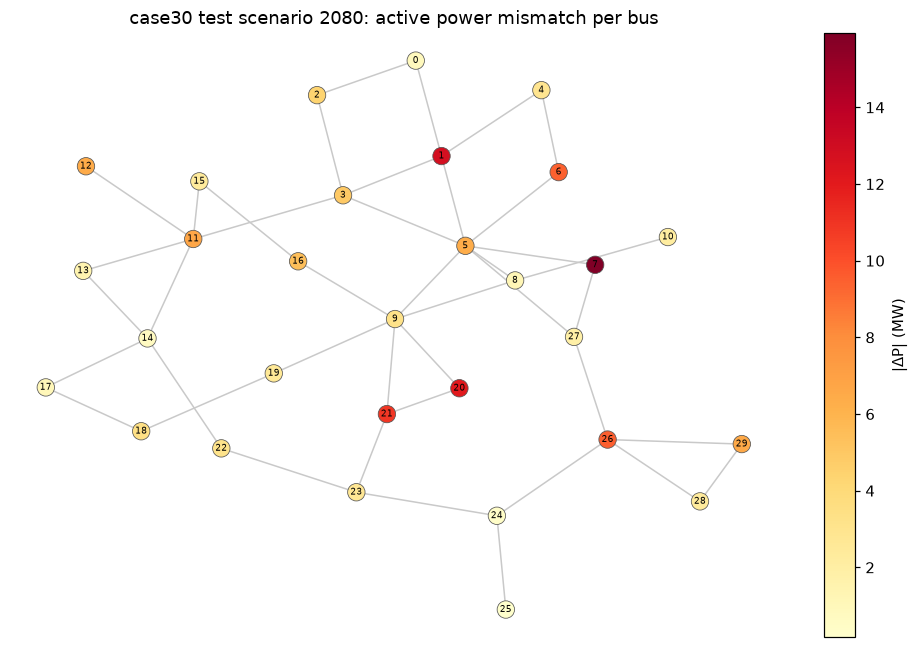

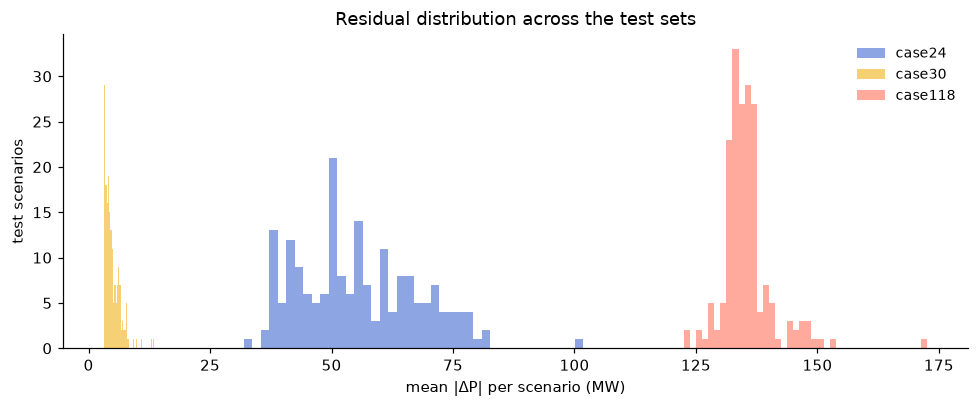

In [7]:
import networkx as nx
import pandapower.topology as top
from gridfm.datagen import build_net

g30 = test_sets["case30"]
intact30 = next(gr for gr in g30 if gr.n_removed == 0)
_, _, (dp_bus, sid30) = ev.pf_evaluate(model, [intact30])

net30 = build_net("case30")
G = top.create_nxgraph(net30)
pos = nx.kamada_kawai_layout(G)
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in net30.line.iterrows():
    ax.plot([pos[row.from_bus][0], pos[row.to_bus][0]],
            [pos[row.from_bus][1], pos[row.to_bus][1]], "-", color="#C9C9C9", lw=1, zorder=0)
for _, row in net30.trafo.iterrows():
    ax.plot([pos[row.hv_bus][0], pos[row.lv_bus][0]],
            [pos[row.hv_bus][1], pos[row.lv_bus][1]], "-", color="#8A8A8A", lw=1.4, zorder=0)
sc = ax.scatter([pos[b][0] for b in G.nodes], [pos[b][1] for b in G.nodes],
                c=[dp_bus[b] for b in G.nodes], cmap="YlOrRd", s=130, zorder=2,
                edgecolor="#555555", lw=0.5)
for b in G.nodes:
    ax.annotate(str(b), pos[b], ha="center", va="center", fontsize=6, zorder=3)
plt.colorbar(sc, ax=ax, label="|ΔP| (MW)")
ax.set_title("case30 test scenario %d: active power mismatch per bus" % sid30)
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "f4_error_map.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.8))
for g in GRIDS:
    ax.hist(results[g].p_res_mw, bins=40, alpha=0.6, color=GRID_COLORS[g], label=g)
ax.set(xlabel="mean |ΔP| per scenario (MW)", ylabel="test scenarios",
       title="Residual distribution across the test sets")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "f5_residual_hist.png", bbox_inches="tight")
plt.show()